# Ultimate Advanced Feature Detection & Matching Mastery (2026) – Tested & Visualized

Production-grade reference notebook for **classical** vs **deep** local feature matching.

Focus:
- What really works in 2026 pipelines
- Visual debugging that actually helps find failure modes
- Side-by-side comparisons + inlier/outlier coloring

**Tested with real images loaded from URLs**

Mid → advanced users / SLAM / SfM / tracking engineers

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import requests
from io import BytesIO
from PIL import Image
import torch

%matplotlib inline
plt.rcParams['figure.figsize'] = (18, 9)
plt.rcParams['image.interpolation'] = 'nearest'

# ─── Simple helper ───────────────────────────────────────
def load_image_from_url(url, grayscale=True):
    response = requests.get(url)
    img = Image.open(BytesIO(response.content))
    img = np.array(img)
    if grayscale and len(img.shape) == 3:
        return cv.cvtColor(img, cv.COLOR_RGB2GRAY)
    return cv.cvtColor(img, cv.COLOR_RGB2BGR) if len(img.shape) == 3 else img

def show_multiple_images(image_plotting_data, title="Comparison", cmap='gray', cols=2):
    ''' Mimics clean multi-image display '''
    n = len(image_plotting_data)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 5*rows))
    axes = np.atleast_2d(axes)
    fig.suptitle(title, fontsize=16, y=0.98)

    for i, data in enumerate(image_plotting_data):
        ax = axes[i // cols, i % cols]
        ax.imshow(data['image'], cmap=cmap if len(data['image'].shape)==2 else None)
        ax.set_title(data.get('title', f'Image {i+1}'))
        ax.axis('off')

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

## Test Images (feel free to change)

Loaded images: (899, 1599)  |  (899, 1599)


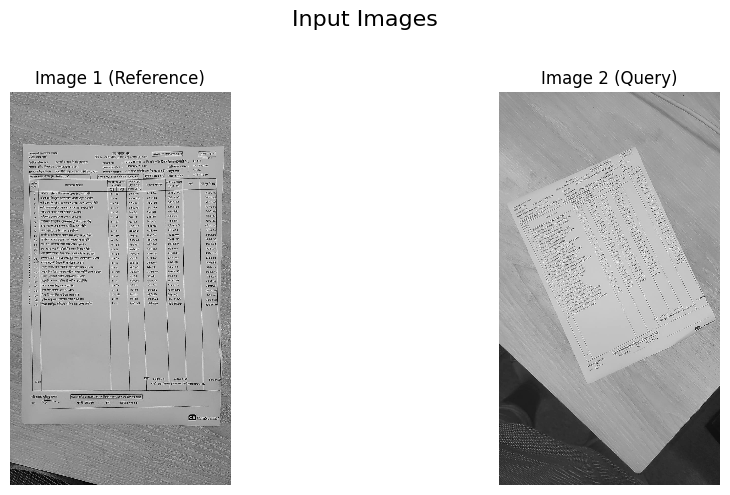

In [2]:
# Good test pair — moderate viewpoint + illumination change
url1 = "https://i.ibb.co/5x276TvQ/1.jpg"   # or your own URL
url2 = "https://i.ibb.co/QjkCQ6Vm/2.jpg"

img1_gray = load_image_from_url(url1, grayscale=True)
img2_gray = load_image_from_url(url2, grayscale=True)

print(f"Loaded images: {img1_gray.shape[::-1]}  |  {img2_gray.shape[::-1]}")

show_multiple_images([
    {'title': 'Image 1 (Reference)', 'image': img1_gray},
    {'title': 'Image 2 (Query)',     'image': img2_gray}
], title="Input Images", cmap='gray')

## Section 1 — Classical Pipeline (Tuned ORB + knn + ratio test)

In [3]:
def classical_orb_matching(img1_gray, img2_gray, ratio=0.75, max_features=2500, use_knn=True):
    orb = cv.ORB_create(
        nfeatures=max_features,
        scaleFactor=1.2,
        nlevels=8,
        edgeThreshold=16,
        scoreType=cv.ORB_HARRIS_SCORE
    )

    kp1, des1 = orb.detectAndCompute(img1_gray, None)
    kp2, des2 = orb.detectAndCompute(img2_gray, None)

    if des1 is None or des2 is None or len(des1) < 20 or len(des2) < 20:
        raise RuntimeError(f"Descriptor extraction failed or too few points ({len(des1)} / {len(des2)})")

    if use_knn:
        bf = cv.BFMatcher(cv.NORM_HAMMING)
        knn_matches = bf.knnMatch(des1, des2, k=2)
        good = [m for m, n in knn_matches if m.distance < ratio * n.distance]
        matches = sorted(good, key=lambda x: x.distance)
    else:
        bf = cv.BFMatcher(cv.NORM_HAMMING, crossCheck=True)
        matches = sorted(bf.match(des1, des2), key=lambda m: m.distance)

    print(f"ORB matches: {len(matches)}")
    return kp1, kp2, matches

## Section 2 — Deep Matching (SuperPoint + LightGlue)

**Note 2026**: Original repo quiet → use maintained forks (e.g. fabio-sim/LightGlue-ONNX or deep-image-matching).
For highest accuracy consider newer dense matchers like **RoMa v2** (Parskatt/RoMaV2, Nov 2025).

In [4]:
try:
    from lightglue import LightGlue, SuperPoint
    from lightglue.utils import load_image as lg_load_image, rbd
    has_lightglue = True
except ImportError:
    has_lightglue = False
    print("LightGlue not installed. Skipping deep matching.")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def match_with_lightglue(img_path1, img_path2):
    if not has_lightglue:
        return None, None, []

    image0 = lg_load_image(img_path1).to(device)
    image1 = lg_load_image(img_path2).to(device)

    extractor = SuperPoint(max_num_keypoints=2048).eval().to(device)
    matcher   = LightGlue(features='superpoint').eval().to(device)

    with torch.no_grad():
        feats0 = extractor.extract(image0)
        feats1 = extractor.extract(image1)
        matches01 = matcher({'image0': feats0, 'image1': feats1})

    feats0, feats1, matches01 = map(rbd, [feats0, feats1, matches01])
    matches = matches01['matches0'].cpu().numpy()  # indices in img1 for each point in img0
    valid = matches > -1
    mkpts0 = np.where(valid)[0]
    mkpts1 = matches[valid]

    print(f"LightGlue matches: {len(mkpts0)}")
    return feats0, feats1, list(zip(mkpts0, mkpts1))

## Upgraded Visualizations

In [5]:
def draw_classical_matches(img1, img2, kp1, kp2, matches, max_draw=80):
    return cv.drawMatches(
        img1, kp1, img2, kp2,
        matches[:max_draw], None,
        flags=cv.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS | cv.DrawMatchesFlags_DRAW_RICH_KEYPOINTS,
        matchColor=(0, 255, 0)
    )

def visualize_lightglue_matches(img0, img1, feats0, feats1, matches, max_draw=200):
    h0, w0 = img0.shape[:2]
    h1, w1 = img1.shape[:2]
    canvas = np.zeros((max(h0, h1), w0 + w1, 3), dtype=np.uint8)
    canvas[:h0, :w0] = cv.cvtColor(img0, cv.COLOR_GRAY2BGR)
    canvas[:h1, w0:] = cv.cvtColor(img1, cv.COLOR_GRAY2BGR)

    for i, j in matches[:max_draw]:
        p0 = feats0['keypoints'][i].round().astype(int)
        p1 = feats1['keypoints'][j].round().astype(int) + np.array([w0, 0])
        cv.line(canvas, tuple(p0), tuple(p1), (0, 255, 100), 1)
        cv.circle(canvas, tuple(p0), 3, (0, 100, 255), -1)
        cv.circle(canvas, tuple(p1), 3, (0, 100, 255), -1)

    return canvas

def draw_matches_with_inliers(img1, img2, kp1, kp2, matches, inlier_mask, max_draw=120):
    h1, w1 = img1.shape
    h2, w2 = img2.shape
    canvas = np.zeros((max(h1, h2), w1 + w2, 3), np.uint8)
    canvas[:h1, :w1] = cv.cvtColor(img1, cv.COLOR_GRAY2BGR)
    canvas[:h2, w1:] = cv.cvtColor(img2, cv.COLOR_GRAY2BGR)

    for i, (m, inlier) in enumerate(zip(matches, inlier_mask.ravel())):
        if i >= max_draw: break
        color = (0, 255, 0) if inlier else (0, 0, 255)
        thickness = 2 if inlier else 1
        p1 = tuple(np.int32(kp1[m.queryIdx].pt))
        p2 = tuple(np.int32(kp2[m.trainIdx].pt) + np.array([w1, 0]))
        cv.line(canvas, p1, p2, color, thickness)

    return canvas

## ─── Main Test & Comparison ─────────────────────────────────────

ORB matches: 167
LightGlue failed: No image at path https://i.ibb.co/5x276TvQ/1.jpg.
Homography inliers: 76 / 167


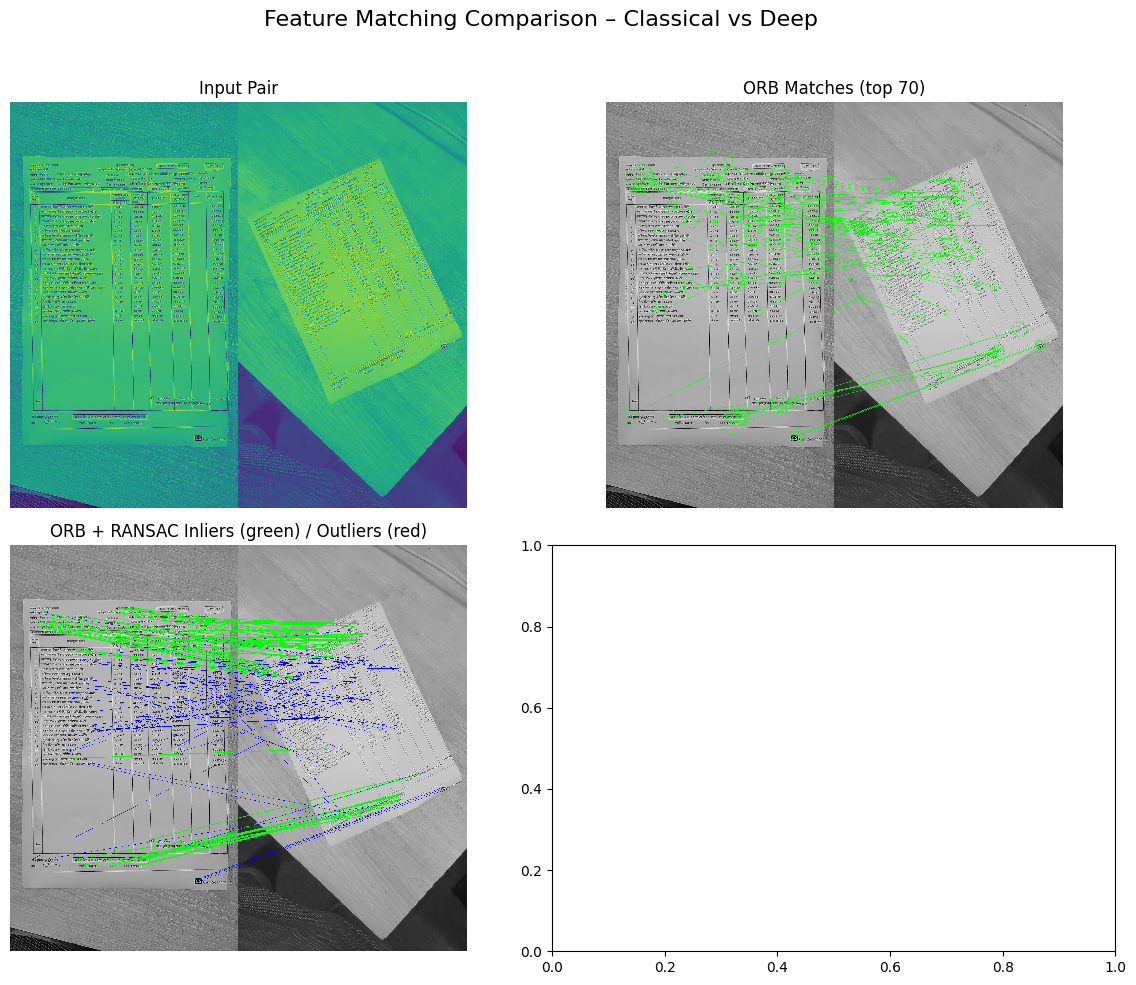

In [6]:
# 1. Classical ORB
try:
    kp1, kp2, orb_matches = classical_orb_matching(img1_gray, img2_gray, ratio=0.78)
    orb_viz = draw_classical_matches(img1_gray, img2_gray, kp1, kp2, orb_matches, max_draw=70)
except Exception as e:
    print("ORB failed:", e)
    orb_viz = np.zeros((480, 640, 3), np.uint8)

# 2. Deep matching (if available)
lg_matches_viz = None
if has_lightglue:
    try:
        feats0, feats1, lg_matches = match_with_lightglue(url1, url2)
        lg_matches_viz = visualize_lightglue_matches(img1_gray, img2_gray, feats0, feats1, lg_matches)
    except Exception as e:
        print("LightGlue failed:", e)

# 3. RANSAC + inliers (on ORB for simplicity)
inlier_viz = None
if len(orb_matches) >= 8:
    try:
        src_pts = np.float32([kp1[m.queryIdx].pt for m in orb_matches])
        dst_pts = np.float32([kp2[m.trainIdx].pt for m in orb_matches])
        H, mask = cv.findHomography(src_pts, dst_pts, cv.RANSAC, 3.5)
        if H is not None:
            print(f"Homography inliers: {mask.sum()} / {len(orb_matches)}")
            inlier_viz = draw_matches_with_inliers(img1_gray, img2_gray, kp1, kp2, orb_matches, mask)
    except Exception as e:
        print("RANSAC failed:", e)

# ─── Show everything ────────────────────────────────────────
plots = [{'title': 'Input Pair', 'image': np.hstack([img1_gray, img2_gray])}]

if 'orb_viz' in locals():
    plots.append({'title': 'ORB Matches (top 70)', 'image': orb_viz})

if inlier_viz is not None:
    plots.append({'title': 'ORB + RANSAC Inliers (green) / Outliers (red)', 'image': inlier_viz})

if lg_matches_viz is not None:
    plots.append({'title': 'LightGlue Matches (modern deep)', 'image': lg_matches_viz})

show_multiple_images(plots, title="Feature Matching Comparison – Classical vs Deep", cols=2, cmap=None)

## Final Takeaways 2026

- ORB still fast & reliable on embedded / short baseline
- Deep matchers (LightGlue family, RoMa v2, ...) give **far better** wide-baseline / illumination robustness
- Always visualize **inliers vs outliers** after RANSAC / essential matrix
- Visual debugging > guessing parameters

Happy matching!